In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
# Загрузка данных Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [10]:
# 2. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# 3. Масштабирование признаков (важно для корректной работы регуляризации)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [13]:
# L1-регуляризация (Lasso)
lr_l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=5000)
lr_l1.fit(X_train_std, y_train)

# L2-регуляризация (Ridge)
lr_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=5000)
lr_l2.fit(X_train_std, y_train)

c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [14]:
# Предсказание и оценка
y_pred_l1 = lr_l1.predict(X_test_std)
y_pred_l2 = lr_l2.predict(X_test_std)

print(f"Accuracy (L1): {accuracy_score(y_test, y_pred_l1):.2f}")
print(f"Accuracy (L2): {accuracy_score(y_test, y_pred_l2):.2f}")

Accuracy (L1): 1.00
Accuracy (L2): 1.00


In [15]:
# Сравнение весов (L1 часто зануляет веса менее важных признаков)
print("\nВеса признаков (первый класс):")
print(f"L1 weights: {lr_l1.coef_[0]}")
print(f"L2 weights: {lr_l2.coef_[0]}")


Веса признаков (первый класс):
L1 weights: [ 0.          0.82565887 -4.31394836  0.        ]
L2 weights: [-0.96229141  1.02709252 -1.74177531 -1.59749108]


In [16]:
from sklearn.model_selection import GridSearchCV

# Сетка параметров: пробуем разные значения C для L1 и L2
param_grid = [
    {'penalty': ['l1'], 'solver': ['saga'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'penalty': ['l2'], 'solver': ['lbfgs'], 'C': [0.01, 0.1, 1, 10, 100]}
]

grid_search = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid_search.fit(X_train_std, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность: {grid_search.best_score_:.2f}")

c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

Лучшие параметры: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Лучшая точность: 0.95


c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

In [17]:
import matplotlib.pyplot as plt

# Построим 2D график на двух признаках
X_vis = iris.data[:, :2]
y_vis = iris.target
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42)

In [18]:
# Обучаем модель на сокращенных данных
model = LogisticRegression(C=1.0).fit(X_train_v, y_train_v)

In [19]:
# Создаем сетку для рисования границ
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [20]:
# Предсказываем класс для каждой точки сетки
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

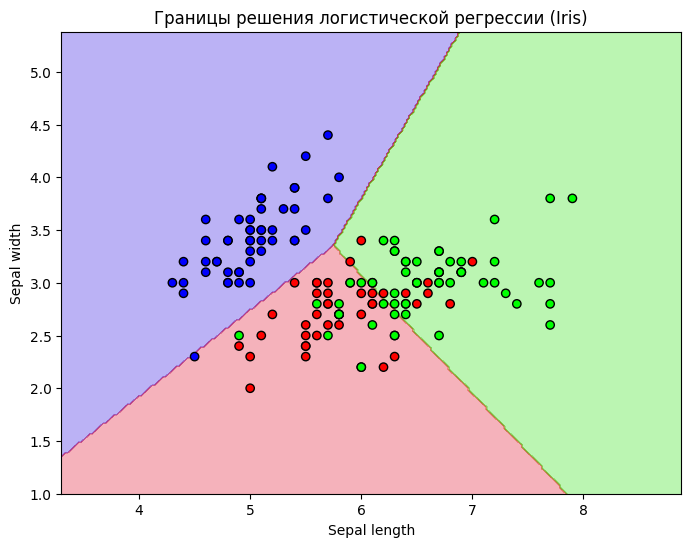

In [21]:
# Визуализация
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.brg)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors='k', cmap=plt.cm.brg)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Границы решения логистической регрессии (Iris)')
plt.show()

Задание.

#1.

Используя логистическую регрессию с L1-регуляризацией, проведите эксперимент.

Загрузите датасет Iris и стандартизируйте его.

Обучите модель LogisticRegression с параметром penalty='l1', solver='liblinear'.

Создайте цикл, который перебирает значения C из списка: [0.001, 0.01, 0.1, 1, 10].

Для каждого значения C выведите количество коэффициентов (весов), которые стали равны абсолютному нулю.

#2.

Обучите две модели: одну с penalty='l1', другую с penalty='l2' при очень маленьком C=0.01.

Выведите на экран веса (model.coef_) для обеих моделей.

В какой модели веса распределены более равномерно?

В какой модели наблюдается резкий контраст между признаками?


In [25]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [26]:
# Подготовка данных
data = load_iris()
X, y = data.data, data.target
X_std = StandardScaler().fit_transform(X)

In [27]:
Cs = [0.001, 0.01, 0.1, 1, 10]

for c in Cs:
    model = LogisticRegression(penalty='l1', C=c, solver='saga', max_iter=5000)
    model.fit(X_std, y)
    zero_count = np.sum(model.coef_ == 0)
    print(f"C={c}: нулевых весов = {zero_count}")

C=0.001: нулевых весов = 12
C=0.01: нулевых весов = 12
C=0.1: нулевых весов = 8
C=1: нулевых весов = 6
C=10: нулевых весов = 5


c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

In [29]:
# Задание 2: сравнение L1 и L2 при C=0.01
model_l1_small = LogisticRegression(penalty='l1', C=0.01, solver='saga', max_iter=5000)
model_l2_small = LogisticRegression(penalty='l2', C=0.01, solver='lbfgs', max_iter=5000)

model_l1_small.fit(X_std, y)
model_l2_small.fit(X_std, y)

print("Весa L1-модели:")
print(model_l1_small.coef_)
print("Весa L2-модели:")
print(model_l2_small.coef_)

# L1 часто есть строгие обнуления, что создаёт резкий контраст между признаками
# L2 веса распределяются более равномерно, без полного обнуления

Весa L1-модели:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Весa L2-модели:
[[-0.20910595  0.20631335 -0.29068063 -0.27664083]
 [ 0.01680258 -0.19567012  0.05738483  0.0071032 ]
 [ 0.19230337 -0.01064323  0.2332958   0.26953763]]


c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\poosh\Documents\nsu\spacy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=